# Movies Project Starter

Use this starter notebook for the BAN 6003 final project option: **The Movies Dataset / MovieLens ratings**.

Run cells from top to bottom first. Then replace starter notes with your own project decisions, checks, and interpretation.

Start each milestone by reading the matching Canvas milestone assignment page. The Canvas page tells you exactly what evidence and submission items are required; this notebook gives you starter spaces to build that work.



## Before You Start: Key Project Hints

This dataset mixes movie-level tables and rating-event-level data. The key skill is controlling granularity.

- A common final ABT is **one row per movie**.
- Do **not** directly merge raw `ratings` into `movies` and assume the result is still one row per movie.
- Aggregate ratings to `movieId` first, then merge the rating summary into the movie table.
- Use `movieId` for ratings and `tmdbId` for curated credits/keywords.
- Average rating is unstable for movies with very few ratings. Use a minimum rating-count threshold before modeling.
- Be careful about leakage: post-release fields such as revenue, popularity, vote count, or rating count may not be valid if your question is pre-release prediction.

## Setup

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "README.md").exists() and (REPO_ROOT.parent / "README.md").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "outputs"
REPORTS_DIR = REPO_ROOT / "reports"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)


## Load Data

Read each provided table. Keep the original row meaning in mind before joining tables.

In [7]:
movies = pd.read_csv(DATA_DIR / 'movies_metadata.csv')
ratings = pd.read_csv(DATA_DIR / 'ratings.csv', parse_dates=['rating_datetime'])
links = pd.read_csv(DATA_DIR / 'links.csv')
credits = pd.read_csv(DATA_DIR / 'credits_curated.csv')
keywords = pd.read_csv(DATA_DIR / 'keywords_curated.csv')

tables = {
    'movies': movies,
    'ratings': ratings,
    'links': links,
    'credits': credits,
    'keywords': keywords,
}

## Basic Data Profile

Use this section for your first pass through row counts, columns, data types, missingness, duplicates, and suspicious values.

In [8]:
for name, df in tables.items():
    print(f'\n{name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
    display(df.head(3))


movies: 9,082 rows x 21 columns


,movieId,tmdbId,imdb_id,title,original_title,original_language,release_date,runtime,budget,revenue,popularity,vote_average,vote_count,genres,production_companies,production_countries,adult,status,genres_list,primary_genre,release_year
0,1,862,tt0114709,Toy Story,Toy Story,en,1995-10-30,81.0,30000000,373554033.0,21.946943,7.7,5415.0,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",False,Released,Animation|Comedy|Family,Animation,1995
1,2,8844,tt0113497,Jumanji,Jumanji,en,1995-12-15,104.0,65000000,262797249.0,17.015539,6.9,2413.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",False,Released,Adventure|Fantasy|Family,Adventure,1995
2,3,15602,tt0113228,Grumpier Old Men,Grumpier Old Men,en,1995-12-22,101.0,0,0.0,11.712900,6.5,92.0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...","[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",False,Released,Romance|Comedy,Romance,1995



ratings: 99,810 rows x 5 columns


,userId,movieId,rating,timestamp,rating_datetime
0,1,31,2.5,1260759144,2009-12-14 02:52:24
1,1,1029,3.0,1260759179,2009-12-14 02:52:59
2,1,1061,3.0,1260759182,2009-12-14 02:53:02



links: 9,125 rows x 3 columns


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0



credits: 9,082 rows x 3 columns


,tmdbId,director,top_cast
0,862,John Lasseter,Tom Hanks|Tim Allen|Don Rickles
1,8844,Joe Johnston,Robin Williams|Jonathan Hyde|Kirsten Dunst
2,15602,Howard Deutch,Walter Matthau|Jack Lemmon|Ann-Margret



keywords: 9,082 rows x 2 columns


,tmdbId,keywords_list
0,862,jealousy|toy|boy|friendship|friends|rivalry|bo...
1,8844,board game|disappearance|based on children's b...
2,15602,fishing|best friend|duringcreditsstinger|old men


In [9]:
profile_rows = []
for name, df in tables.items():
    profile_rows.append({
        'table': name,
        'rows': len(df),
        'columns': df.shape[1],
        'duplicate_rows': int(df.duplicated().sum()),
        'missing_cells': int(df.isna().sum().sum()),
    })
pd.DataFrame(profile_rows)

,table,rows,columns,duplicate_rows,missing_cells
0,movies,9082,21,0,72
1,ratings,99810,5,0,0
2,links,9125,3,0,13
3,credits,9082,3,0,114
4,keywords,9082,2,0,761


Observation: The datasets have different levels of granularity. The movies, credits, and keywords tables contain movie-level information, while the ratings table contains individual user-movie rating events. Therefore, ratings must be aggregated by movieId before being joined to a one-row-per-movie ABT.

### Key and Granularity Audit

Use the expected key for each table before planning joins. `ratings` is the exception: its row meaning is a user-movie rating event, so check the combined `userId`-`movieId` key rather than expecting `movieId` alone to be unique. `links` is a crosswalk; because `movies` already contains both IDs, use it for validation unless your analysis needs one of its fields.


In [10]:
key_audit = pd.DataFrame([
    {"table": "movies", "expected_key": "movieId", "duplicate_keys": movies["movieId"].duplicated().sum(), "missing_key_values": movies["movieId"].isna().sum()},
    {"table": "movies", "expected_key": "tmdbId", "duplicate_keys": movies["tmdbId"].duplicated().sum(), "missing_key_values": movies["tmdbId"].isna().sum()},
    {"table": "ratings", "expected_key": "userId + movieId", "duplicate_keys": ratings[["userId", "movieId"]].duplicated().sum(), "missing_key_values": ratings[["userId", "movieId"]].isna().sum().sum()},
    {"table": "links", "expected_key": "movieId", "duplicate_keys": links["movieId"].duplicated().sum(), "missing_key_values": links["movieId"].isna().sum()},
    {"table": "credits", "expected_key": "tmdbId", "duplicate_keys": credits["tmdbId"].duplicated().sum(), "missing_key_values": credits["tmdbId"].isna().sum()},
    {"table": "keywords", "expected_key": "tmdbId", "duplicate_keys": keywords["tmdbId"].duplicated().sum(), "missing_key_values": keywords["tmdbId"].isna().sum()},
])

key_audit


,table,expected_key,duplicate_keys,missing_key_values
0,movies,movieId,0,0
1,movies,tmdbId,0,0
2,ratings,userId + movieId,0,0
3,links,movieId,0,0
4,credits,tmdbId,0,0
5,keywords,tmdbId,0,0


Observation: No duplicate values were found for the expected keys. The combination of userId and movieId is unique in the ratings table. The key structure appears suitable for later aggregation and integration.

## Milestone 1 Starter: Initial Profile and Cleaning Plan

Complete this by the first project milestone.

Write notes on:

- Business problem and decision context
- Raw tables and row meaning
- Initial row and column counts
- Data type issues
- Missing values and duplicates
- Suspicious values
- Proposed target/outcome
- Early ethics or governance concerns

Important Movies notes:

- `movies` is movie-level, while `ratings` is user-movie rating-event-level.
- `credits` and `keywords` are curated movie-level tables connected by `tmdbId`.
- Budget and revenue may contain zero or missing-like values; describe this before using them.
- Decide whether your project is about audience ratings, catalog strategy, revenue, popularity, or genre/content patterns.

### Read the Canvas milestone page first

Before you start this section, read the matching Canvas milestone assignment page. The Canvas page is the authoritative checklist for what you need to submit, how the milestone is graded, and what evidence should appear in your notebook/report. Use this starter section as a workspace, not as a replacement for the Canvas instructions.



### Milestone 1 written workspace

Use this cell to draft the narrative required by the Canvas Milestone 1 page.

- Business or research question:
What movie characteristics are associated with higher user ratings?

- Why this question matters:
Understanding which movie characteristics are associated with higher user ratings can help streaming platforms and content teams make better decisions about which types of movies to promote or acquire.

- Tables/files used:
movies_metadata.csv, ratings.csv, links.csv, credits_curated.csv, and keywords_curated.csv.

- Dataset description/source:
The project uses the curated Movies Project dataset provided with the BAN 6003 final project template. It includes movie metadata, user ratings, movie ID links, credits, and keywords. The provided data/README.md documents the row meaning, expected keys, and integration guidance for each file.  
Project template/source: https://github.com/tianhaiz/ban6003-project-option-1-movies-template

- Row meaning of each important table: 
In movies_metadata.csv, one row represents one movie. In ratings.csv, one row represents one rating given by a user to a movie. In links.csv, one row represents one movie and provides the IDs used to connect the datasets. In credits_curated.csv, one row represents one movie with its director and top cast information. In keywords_curated.csv, one row represents one movie with its associated keywords.

- Important fields: movieId and tmdbId are the main identifiers used to connect the datasets. The rating field contains user ratings, while fields such as release_year, runtime, budget, revenue, primary_genre, director, top_cast, and keywords_list describe movie characteristics that may be examined in the analysis.

- Early data quality issues:
The profiling identified missing values in several fields, including status, genres_list, primary_genre, tmdbId in the links table, director, top_cast, and keywords_list. There are also 4,443 movies with a budget of 0, 4,322 with revenue of 0, and 20 movies with runtime less than or equal to 0. These zero values need further review because they may represent missing or unknown information rather than actual values. No exact duplicate rows or duplicate key values were found.

- Data type issues:
The release_date field is currently stored as a string and may need to be converted to a date type for analysis. Also, tmdbId in the links table is stored as a float because it contains missing values, while tmdbId in the other movie-level tables is stored as an integer. These data types will be reviewed and standardized before joining the datasets.

- Initial cleaning plan:
I will review the missing values and determine whether they should be kept, filled, or excluded depending on the field and the analysis. I will investigate zero values in budget, revenue, and runtime before deciding how to handle them. I will also standardize data types where needed, especially IDs and dates. Before creating the movie-level ABT, I will aggregate the ratings by movieId and then merge the datasets using the appropriate movie identifiers.

- Possible target/outcome:
A possible target is high_user_rating. Following the project guidance, this target will only be defined for movies with at least 20 user ratings. Movies with fewer than 20 ratings will have an undefined target rather than being classified as low-rated.

- Ethics, privacy, or governance concerns:
User ratings represent the opinions of the users in the dataset and should not be treated as an objective measure of movie quality. Individual user rating behavior should also remain private, so the analysis will use aggregated movie-level ratings rather than individual user-level information. The raw data will be preserved, and cleaning and transformation steps will be documented for reproducibility.


In [11]:
# Milestone 1 code workspace
# Add your additional profiling checks here.
# Examples: missingness by important columns, duplicate key checks, suspicious value checks.

for name, df in tables.items():
    print(f"\n{name.upper()} DATA TYPES")
    print(df.dtypes)



MOVIES DATA TYPES
movieId                   int64
tmdbId                    int64
imdb_id                     str
title                       str
original_title              str
original_language           str
release_date                str
runtime                 float64
budget                    int64
revenue                 float64
popularity              float64
vote_average            float64
vote_count              float64
genres                      str
production_companies        str
production_countries        str
adult                      bool
status                      str
genres_list                 str
primary_genre               str
release_year              int64
dtype: object

RATINGS DATA TYPES
userId                      int64
movieId                     int64
rating                    float64
timestamp                   int64
rating_datetime    datetime64[us]
dtype: object

LINKS DATA TYPES
movieId      int64
imdbId       int64
tmdbId     float64
dtype: object

C

Observation: Most data types appear appropriate, but release_date is stored as a string and may need to be converted to a date type. Also, tmdbId in the links table is stored as a float because it contains missing values, while tmdbId in the other movie-level tables is stored as an integer.

In [12]:
# Check missing values in each dataset
for name, df in tables.items():
    print(f"\n{name.upper()} MISSING VALUES")
    print(df.isna().sum())


MOVIES MISSING VALUES
movieId                  0
tmdbId                   0
imdb_id                  0
title                    0
original_title           0
original_language        0
release_date             0
runtime                  0
budget                   0
revenue                  0
popularity               0
vote_average             0
vote_count               0
genres                   0
production_companies     0
production_countries     0
adult                    0
status                   2
genres_list             35
primary_genre           35
release_year             0
dtype: int64

RATINGS MISSING VALUES
userId             0
movieId            0
rating             0
timestamp          0
rating_datetime    0
dtype: int64

LINKS MISSING VALUES
movieId     0
imdbId      0
tmdbId     13
dtype: int64

CREDITS MISSING VALUES
tmdbId       0
director    24
top_cast    90
dtype: int64

KEYWORDS MISSING VALUES
tmdbId             0
keywords_list    761
dtype: int64


Observation: Missing values are concentrated in a few fields. The largest amount of missing data is in keywords_list with 761 missing values. Smaller amounts are present in top_cast, director, genres_list, primary_genre, status, and tmdbId in the links table. The ratings table has no missing values.

In [13]:
# Check duplicate rows in each dataset
for name, df in tables.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

movies: 0 duplicate rows
ratings: 0 duplicate rows
links: 0 duplicate rows
credits: 0 duplicate rows
keywords: 0 duplicate rows


Observation: No exact duplicate rows were found in any of the five datasets, so duplicate records do not appear to be a major data quality issue at this stage.

In [14]:
# Check suspicious or confusing values in important movie fields
print("Movies with budget = 0:", (movies["budget"] == 0).sum())
print("Movies with revenue = 0:", (movies["revenue"] == 0).sum())
print("Movies with runtime <= 0:", (movies["runtime"] <= 0).sum())

print("\nRating distribution:")
print(ratings["rating"].describe())

Movies with budget = 0: 4443
Movies with revenue = 0: 4322
Movies with runtime <= 0: 20

Rating distribution:
count    99810.000000
mean         3.542972
std          1.057939
min          0.500000
25%          3.000000
50%          4.000000
75%          4.000000
max          5.000000
Name: rating, dtype: float64


Observation: A large number of movies have zero values for budget and revenue, which may represent unknown or missing information rather than true zero values. The 20 movies with nonpositive runtime also need further review. User ratings range from 0.5 to 5.0, with an average of about 3.54.

In [15]:
# Check duplicate important keys
print("Duplicate movieId values in movies:", movies["movieId"].duplicated().sum())
print("Duplicate tmdbId values in movies:", movies["tmdbId"].duplicated().sum())
print("Duplicate movieId values in links:", links["movieId"].duplicated().sum())
print("Duplicate tmdbId values in credits:", credits["tmdbId"].duplicated().sum())
print("Duplicate tmdbId values in keywords:", keywords["tmdbId"].duplicated().sum())

print(
    "Duplicate userId + movieId combinations in ratings:",
    ratings.duplicated(subset=["userId", "movieId"]).sum()
)

Duplicate movieId values in movies: 0
Duplicate tmdbId values in movies: 0
Duplicate movieId values in links: 0
Duplicate tmdbId values in credits: 0
Duplicate tmdbId values in keywords: 0
Duplicate userId + movieId combinations in ratings: 0


 Observation: No duplicate values were found in the important identifier fields, including movieId, tmdbId, and the combined userId and movieId rating key. This supports using these identifiers for later aggregation and integration of the datasets.

In [16]:
# Summarize row and column counts for each dataset
for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

movies: 9082 rows, 21 columns
ratings: 99810 rows, 5 columns
links: 9125 rows, 3 columns
credits: 9082 rows, 3 columns
keywords: 9082 rows, 2 columns


Observation: The five datasets differ substantially in size because they represent different types of information. The ratings table is the largest with 99,810 user-movie rating records, while the movie-level tables contain approximately 9,000 records. These differences reinforce the need to preserve the correct row meaning when the datasets are later integrated.

In [17]:
# Examine how many user ratings each movie has
rating_counts = ratings.groupby("movieId").size()

print("Number of movies with at least one rating:", len(rating_counts))
print("Movies with 1-4 ratings:", (rating_counts < 5).sum())
print("Movies with 5-19 ratings:", ((rating_counts >= 5) & (rating_counts < 20)).sum())
print("Movies with 20 or more ratings:", (rating_counts >= 20).sum())

print("\nRating count per movie:")
print(rating_counts.describe())

Number of movies with at least one rating: 9025
Movies with 1-4 ratings: 5540
Movies with 5-19 ratings: 2185
Movies with 20 or more ratings: 1300

Rating count per movie:
count    9025.000000
mean       11.059280
std        24.095433
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       341.000000
dtype: float64


Observation: Rating coverage varies considerably across movies. Of the 9,025 movies with at least one rating, 5,540 have only 1–4 ratings, while 1,300 have 20 or more ratings. The median movie has only 3 ratings. This shows that an average rating based on only a few users may not be very reliable, which supports using a minimum rating-count threshold before defining the high_user_rating outcome.

In [18]:
# Check movie coverage across the different datasets
rated_movie_ids = set(ratings["movieId"])
movie_ids = set(movies["movieId"])

print("Movies in movies_metadata:", len(movie_ids))
print("Movies with at least one rating:", len(movie_ids & rated_movie_ids))
print("Movies with no ratings:", len(movie_ids - rated_movie_ids))

movie_tmdb_ids = set(movies["tmdbId"])
credit_tmdb_ids = set(credits["tmdbId"])
keyword_tmdb_ids = set(keywords["tmdbId"])

print("\nMovies with matching credits:",
      len(movie_tmdb_ids & credit_tmdb_ids))
print("Movies without matching credits:",
      len(movie_tmdb_ids - credit_tmdb_ids))

print("Movies with matching keyword records:",
      len(movie_tmdb_ids & keyword_tmdb_ids))
print("Movies without matching keyword records:",
      len(movie_tmdb_ids - keyword_tmdb_ids))

Movies in movies_metadata: 9082
Movies with at least one rating: 9025
Movies with no ratings: 57

Movies with matching credits: 9082
Movies without matching credits: 0
Movies with matching keyword records: 9082
Movies without matching keyword records: 0


 Observation: Most movies in the metadata have user rating information, but 57 of the 9,082 movies have no ratings. In contrast, all movies have matching records in both the credits and keywords tables based on tmdbId. The 57 movies without ratings will need to be considered when creating a rating-based outcome because a user-rating measure cannot be calculated for them.

In [19]:
# Examine the time coverage of the movie dataset
print("Earliest release year:", movies["release_year"].min())
print("Latest release year:", movies["release_year"].max())

movies_by_decade = (
    (movies["release_year"] // 10 * 10)
    .value_counts()
    .sort_index()
)

print("\nNumber of movies by decade:")
print(movies_by_decade)

Earliest release year: 1902
Latest release year: 2016

Number of movies by decade:
release_year
1900       1
1910       6
1920      56
1930     148
1940     250
1950     341
1960     443
1970     549
1980    1193
1990    2193
2000    2533
2010    1369
Name: count, dtype: int64


Observation: The movies in the dataset span from 1902 to 2016, but the number of movies is not evenly distributed across time. The dataset contains relatively few movies from the early decades and many more from the 1980s through the 2010s, with the largest number in the 2000s. This time imbalance should be considered when interpreting patterns involving release year because some periods are represented much more heavily than others.

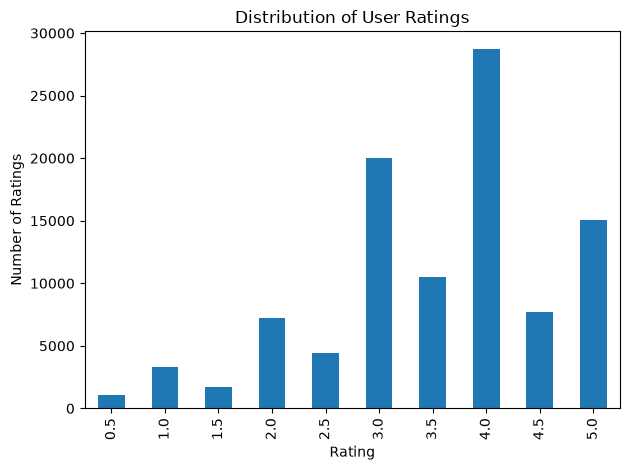

In [20]:
# Visualize the distribution of individual user ratings
rating_frequency = ratings["rating"].value_counts().sort_index()

ax = rating_frequency.plot(
    kind="bar",
    title="Distribution of User Ratings",
    xlabel="Rating",
    ylabel="Number of Ratings"
)

ax.figure.tight_layout()

Observation: User ratings are not evenly distributed across the 0.5–5.0 scale. A rating of 4.0 is the most common, while very low ratings occur much less frequently. Overall, the distribution is concentrated toward the higher end of the rating scale. This pattern should be considered when defining and interpreting the high_user_rating outcome.

In [21]:
# Summary of Data Types and Missing Value Rates
for name, df in tables.items():
    print(f'\n{name}')
    display(df.dtypes.to_frame('dtype').head(20))
    display(df.isna().mean().sort_values(ascending=False).head(10).to_frame('missing_rate'))


movies


,dtype
movieId,int64
tmdbId,int64
imdb_id,str
title,str
original_title,str
original_language,str
release_date,str
runtime,float64
budget,int64
revenue,float64


,missing_rate
genres_list,0.003854
primary_genre,0.003854
status,0.000220
tmdbId,0.000000
movieId,0.000000
original_title,0.000000
title,0.000000
imdb_id,0.000000
original_language,0.000000
revenue,0.000000



ratings


,dtype
userId,int64
movieId,int64
rating,float64
timestamp,int64
rating_datetime,datetime64[us]


...

,dtype
tmdbId,int64
director,str
top_cast,str


,missing_rate
top_cast,0.009910
director,0.002643
tmdbId,0.000000



keywords


,dtype
tmdbId,int64
keywords_list,str


,missing_rate
keywords_list,0.083792
tmdbId,0.000000


Observation: This summary confirms the earlier profiling results. Most fields have appropriate data types and low missing-value rates. The largest missing-value rate is in keywords_list at about 8.4%, while the ratings table has no missing values. The tmdbId field in the links table is stored as a float because some values are missing, and release_date is stored as a string. These issues will be addressed during the cleaning and integration steps.

## Milestone 2 Starter: Integration, Transformation, and Preliminary ABT

Build a preliminary ABT. State exactly what one row means, what keys define one row, and what tables were joined or aggregated.

Critical integration reminder:

Before creating a movie-level ABT, aggregate ratings. Examples include:

- average rating by `movieId`
- rating count by `movieId`
- rating standard deviation by `movieId`
- first and last rating date by `movieId`
- distinct user count by `movieId`

After merging, validate that `movieId` is not duplicated in the ABT.

### Read the Canvas milestone page first

Before you start this section, read the matching Canvas milestone assignment page. The Canvas page is the authoritative checklist for what you need to submit, how the milestone is graded, and what evidence should appear in your notebook/report. Use this starter section as a workspace, not as a replacement for the Canvas instructions.



### Milestone 2 written workspace

Use this cell to document the ABT design required by the Canvas Milestone 2 page.

- Final or preliminary unit of analysis:
- Primary key for one row:
- Tables aggregated before joining:
- Tables joined directly:
- Row-count validation after each major merge:
- New variables created:
- Remaining data quality concerns:



In [ ]:
# Milestone 2 code workspace
# Build or revise your ABT here.
# Add row-count checks and duplicate-key checks after each major merge.



In [ ]:
rating_summary = (
    ratings.groupby("movieId")
    .agg(
        user_rating_mean=("rating", "mean"),
        user_rating_count=("rating", "size"),
        user_rating_std=("rating", "std"),
        first_rating_date=("rating_datetime", "min"),
        last_rating_date=("rating_datetime", "max")
    )
    .reset_index()
)

abt = (
    movies
    .merge(rating_summary, on="movieId", how="left", validate="one_to_one")
    .merge(credits, on="tmdbId", how="left", validate="one_to_one")
    .merge(keywords, on="tmdbId", how="left", validate="one_to_one")
)

abt["has_revenue"] = (pd.to_numeric(abt["revenue"], errors="coerce") > 0).astype("Int64")
abt["rating_target_eligible"] = abt["user_rating_count"].ge(20)
abt["high_user_rating"] = (
    abt["user_rating_mean"].ge(3.75)
    .where(abt["rating_target_eligible"])
    .astype("Int64")
)


In [ ]:
abt_validation = pd.Series({
    "movie_rows_before_merges": len(movies),
    "abt_rows_after_merges": len(abt),
    "duplicate_movie_ids": abt["movieId"].duplicated().sum(),
    "duplicate_tmdb_ids": abt["tmdbId"].duplicated().sum(),
    "movies_with_rating_summary": abt["user_rating_count"].notna().sum(),
    "movies_eligible_for_rating_target": abt["high_user_rating"].notna().sum(),
})

display(abt_validation)
display(abt.head())
display(abt.isna().mean().sort_values(ascending=False).head(15).to_frame("missing_rate"))


Preliminary ABT shape: (9082, 32)


,movieId,tmdbId,imdb_id,title,original_title,original_language,release_date,runtime,budget,revenue,popularity,vote_average,vote_count,genres,production_companies,production_countries,adult,status,genres_list,primary_genre,release_year,user_rating_mean,user_rating_count,user_rating_std,first_rating_date,last_rating_date,director,top_cast,keywords_list,has_revenue,high_user_rating,well_rated_enough_data
0,1,862,tt0114709,Toy Story,Toy Story,en,1995-10-30,81.0,30000000,373554033.0,21.946943,7.7,5415.0,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",False,Released,Animation|Comedy|Family,Animation,1995,3.872470,247.0,0.958981,1996-03-30 19:00:13,2016-10-06 19:55:11,John Lasseter,Tom Hanks|Tim Allen|Don Rickles,jealousy|toy|boy|friendship|friends|rivalry|bo...,1,1,1
1,2,8844,tt0113497,Jumanji,Jumanji,en,1995-12-15,104.0,65000000,262797249.0,17.015539,6.9,2413.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",False,Released,Adventure|Fantasy|Family,Adventure,1995,3.401869,107.0,0.880714,1996-03-30 19:12:30,2016-08-01 17:42:33,Joe Johnston,Robin Williams|Jonathan Hyde|Kirsten Dunst,board game|disappearance|based on children's b...,1,0,0
2,3,15602,tt0113228,Grumpier Old Men,Grumpier Old Men,en,1995-12-22,101.0,0,0.0,11.712900,6.5,92.0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...","[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",False,Released,Romance|Comedy,Romance,1995,3.161017,59.0,1.150115,1996-06-05 06:19:04,2016-08-16 22:07:21,Howard Deutch,Walter Matthau|Jack Lemmon|Ann-Margret,fishing|best friend|duringcreditsstinger|old men,0,0,0
3,4,31357,tt0114885,Waiting to Exhale,Waiting to Exhale,en,1995-12-22,127.0,16000000,81452156.0,3.859495,6.1,34.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",False,Released,Comedy|Drama|Romance,Comedy,1995,2.384615,13.0,0.938835,1996-06-10 16:45:35,2004-07-27 06:14:12,Forest Whitaker,Whitney Houston|Angela Bassett|Loretta Devine,based on novel|interracial relationship|single...,1,0,0
4,5,11862,tt0113041,Father of the Bride Part II,Father of the Bride Part II,en,1995-02-10,106.0,0,76578911.0,8.387519,5.7,173.0,"[{'id': 35, 'name': 'Comedy'}]","[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",False,Released,Comedy,Comedy,1995,3.267857,56.0,0.948512,1996-04-14 14:23:59,2016-08-16 22:15:47,Charles Shyer,Steve Martin|Diane Keaton|Martin Short,baby|midlife crisis|confidence|aging|daughter|...,1,0,0


,missing_rate
user_rating_std,0.341224
keywords_list,0.083792
top_cast,0.009910
last_rating_date,0.006276
first_rating_date,0.006276
user_rating_count,0.006276
user_rating_mean,0.006276
primary_genre,0.003854
genres_list,0.003854
director,0.002643


### SQL Validation Connected to the ABT

The project milestone asks for database or SQL work that supports the workflow. This in-memory SQLite check verifies the movie-level ABT row count and key uniqueness without creating another permanent database file.


In [ ]:
import sqlite3

with sqlite3.connect(":memory:") as connection:
    abt.to_sql("movies_abt", connection, if_exists="replace", index=False)
    sql_abt_check = pd.read_sql_query(
        """
        SELECT
            COUNT(*) AS abt_rows,
            COUNT(DISTINCT movieId) AS unique_movie_ids,
            SUM(CASE WHEN high_user_rating IS NULL THEN 1 ELSE 0 END) AS target_not_defined_rows
        FROM movies_abt;
        """,
        connection,
    )

sql_abt_check


### Data Dictionary Starter

Complete the text fields for every column you keep in the final ABT. Remove unused columns before finalizing the dictionary so the documentation and exported ABT stay aligned.


In [ ]:
data_dictionary = pd.DataFrame({
    "column_name": abt.columns,
    "data_type": [str(abt[column].dtype) for column in abt.columns],
    "description": "",
    "source": "",
    "transformation_or_derivation": "",
    "notes_or_concerns": "",
})

# Hint: use .loc[] to document one column at a time, following the Week 11 pattern.
data_dictionary.head()


## Milestone 3 Starter: Prepared Dataset and Initial Model Application

Choose a target/outcome and features. Start simple. Your first model should be correct and interpretable before it becomes complex.

Modeling reminder:

- If you model `high_user_rating`, use only rows where that nullable target is defined; these movies have at least 20 ratings.
- State when the prediction is meant to occur. For a pre-release question, exclude post-release fields such as revenue, popularity, vote count, rating summaries, and rating dates.
- Do not interpret a rating model as proving artistic quality or causal effects.


### Read the Canvas milestone page first

Before you start this section, read the matching Canvas milestone assignment page. The Canvas page is the authoritative checklist for what you need to submit, how the milestone is graded, and what evidence should appear in your notebook/report. Use this starter section as a workspace, not as a replacement for the Canvas instructions.



### Milestone 3 written workspace

Use this cell to document the prepared dataset and initial model/analysis required by the Canvas Milestone 3 page.

- Target/outcome:
- Feature variables:
- Rows included/excluded and why:
- Train/test split or evaluation plan:
- Baseline model or analysis:
- Initial metrics/results:
- Interpretation limits:



In [ ]:
# Milestone 3 code workspace
# Suggested sequence:
# 1. State the prediction or analysis timing in markdown.
# 2. Filter to rows where your target is defined.
# 3. Select only features available at that time.
# 4. Check class balance or the target distribution.
# 5. Create a reproducible train/test split when modeling.
# 6. Fit a simple baseline and evaluate it on test data.


In [ ]:
# Example placeholder. Replace with your chosen target and feature set.
# target = 'your_target_column'
# features = ['feature_1', 'feature_2']
# model_df = abt[[target] + features].dropna()

abt.describe(include='all').T.head(25)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
movieId,9082.0,NaN,NaN,NaN,30963.741577,1.0,2843.25,6265.5,56026.25,163949.0,40659.690679
tmdbId,9082.0,NaN,NaN,NaN,38710.463885,2.0,9446.25,15775.0,39010.25,416437.0,62123.411079
imdb_id,9082,9082,tt0114709,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,9082,8809,Hamlet,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_title,9082,8841,Hamlet,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_language,9082,42,en,7947,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_date,9082,6002,1994-01-01,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
runtime,9082.0,NaN,NaN,NaN,105.661418,0.0,93.0,102.0,115.0,1140.0,30.350712
budget,9082.0,NaN,NaN,NaN,16647890.737833,0.0,0.0,100000.0,20000000.0,380000000.0,33452764.781378
revenue,9082.0,NaN,NaN,NaN,49187276.79586,0.0,0.0,271608.0,36725282.5,2787965087.0,130180082.298936


## Final Project Starter: Interpretation, Ethics, and Recommendations

Use this section to connect your analysis back to a business or research decision.

Address:

- Main finding
- What the model/analysis can and cannot support
- Limitations
- Ethics or responsible use concerns
- 2-3 cautious recommendations

### Read the Canvas final submission page first

Before completing this section, read the Canvas final submission assignment page. The Canvas page is the authoritative checklist for the final notebook, HTML report, required files, and submission format. Use this section to organize your final evidence and interpretation.



### Final report written workspace

Use this cell to draft the final interpretation required by the Canvas final submission page.

- Main finding:
- Evidence supporting the finding:
- Business or research implication:
- Limitations:
- Ethics/responsible use concerns:
- Recommendations:
- What you would improve with more time:



In [ ]:
# Final project code workspace
# Save final datasets, figures, or tables here when they are ready.
# Recommended filenames:
# final_abt_path = OUTPUT_DIR / "movies_final_abt.csv"
# dictionary_path = OUTPUT_DIR / "movies_data_dictionary.csv"
# metrics_path = OUTPUT_DIR / "movies_model_metrics.csv"
# report_path = REPORTS_DIR / "movies_final_report.html"


In [ ]:
# Save final deliverables only after your ABT and documentation are complete.
# abt.to_csv(OUTPUT_DIR / "movies_final_abt.csv", index=False)
# data_dictionary.to_csv(OUTPUT_DIR / "movies_data_dictionary.csv", index=False)

# Before final submission, restart the kernel, run all cells, and export the notebook to HTML.
